In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Carregar dataset
df = pd.read_csv("/content/acessos_sistema.csv")

# Visualizar primeiras linhas
print("Primeiras linhas do dataset:")
print(df.head())

# Informações gerais
print("\nInformações do dataset:")
print(df.info())

# Estatísticas descritivas
print("\nEstatísticas descritivas:")
print(df.describe())

# Verificar valores nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())

Primeiras linhas do dataset:
   hora_acesso  duracao_sessao_min  numero_tentativas_login  \
0            9                  35                        1   
1           10                  40                        1   
2           11                  25                        1   
3           14                  50                        1   
4           15                  45                        1   

   ip_diferente_habitual  quantidade_paginas_acessadas  
0                      0                            12  
1                      0                            15  
2                      0                             9  
3                      0                            18  
4                      0                            16  

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   hora

In [9]:
# Selecionar todas as colunas para o modelo
features = ["hora_acesso", "duracao_sessao_min", "numero_tentativas_login",
            "ip_diferente_habitual", "quantidade_paginas_acessadas"]

X = df[features]

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

# Predições: -1 = anomalia, 1 = normal
df["anomaly"] = model.predict(X_scaled)
df["anomaly_score"] = model.decision_function(X_scaled)
df["anomaly_label"] = df["anomaly"].map({1: "Normal", -1: "Anômalo"})

print("\nContagem de registros por classe:")
print(df["anomaly_label"].value_counts())


Contagem de registros por classe:
anomaly_label
Normal     76
Anômalo     4
Name: count, dtype: int64


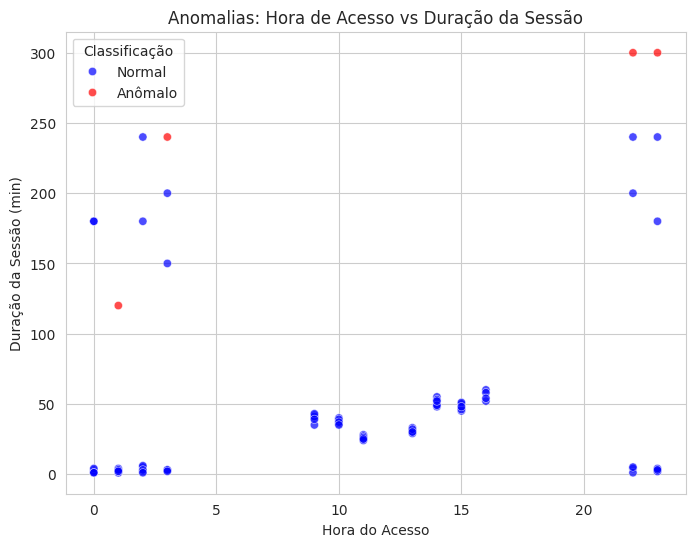

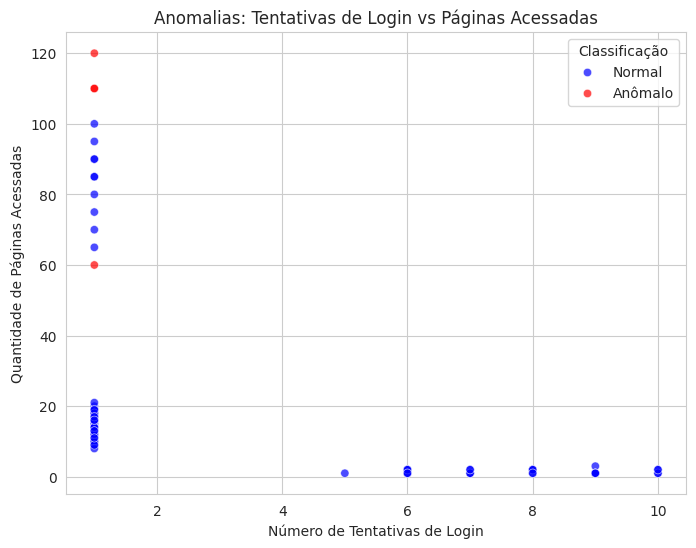

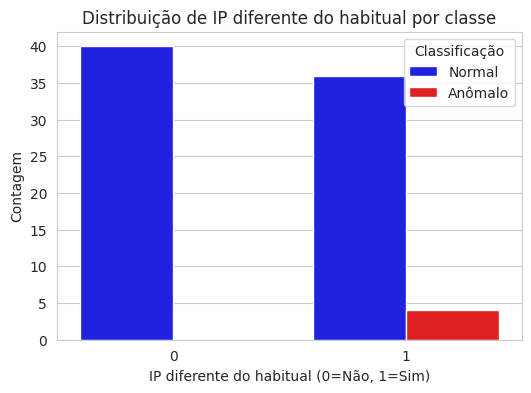

In [11]:
# Configuração de estilo
sns.set_style("whitegrid")

# Gráfico 1: hora_acesso vs duracao_sessao_min
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="hora_acesso", y="duracao_sessao_min",
                hue="anomaly_label", palette={"Normal": "blue", "Anômalo": "red"}, alpha=0.7)
plt.title("Anomalias: Hora de Acesso vs Duração da Sessão")
plt.xlabel("Hora do Acesso")
plt.ylabel("Duração da Sessão (min)")
plt.legend(title="Classificação")
plt.show()

# Gráfico 2: numero_tentativas_login vs quantidade_paginas_acessadas
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="numero_tentativas_login", y="quantidade_paginas_acessadas",
                hue="anomaly_label", palette={"Normal": "blue", "Anômalo": "red"}, alpha=0.7)
plt.title("Anomalias: Tentativas de Login vs Páginas Acessadas")
plt.xlabel("Número de Tentativas de Login")
plt.ylabel("Quantidade de Páginas Acessadas")
plt.legend(title="Classificação")
plt.show()

# Gráfico 3: ip_diferente_habitual – contagem por classe (podemos usar boxplot ou countplot)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="ip_diferente_habitual", hue="anomaly_label",
              palette={"Normal": "blue", "Anômalo": "red"})
plt.title("Distribuição de IP diferente do habitual por classe")
plt.xlabel("IP diferente do habitual (0=Não, 1=Sim)")
plt.ylabel("Contagem")
plt.legend(title="Classificação")
plt.show()

In [12]:
anomalias = df[df["anomaly_label"] == "Anômalo"]
print("Registros considerados anômalos:")
display(anomalias)

Registros considerados anômalos:


,hora_acesso,duracao_sessao_min,numero_tentativas_login,ip_diferente_habitual,quantidade_paginas_acessadas,anomaly,anomaly_score,anomaly_label
42,1,120,1,1,60,-1,-0.036204,Anômalo
54,23,300,1,1,110,-1,-0.042807,Anômalo
71,22,300,1,1,120,-1,-0.065891,Anômalo
75,3,240,1,1,110,-1,-0.010563,Anômalo
